In [3]:
from datasets import load_dataset
from huggingface_hub import login
from nltk.util import ngrams
from nltk import FreqDist
import re

print("Libraries imported successfully.")

try:
    print("Successfully logged into Hugging Face Hub.")
except Exception as e:
    print(f"Could not log in to Hugging Face Hub. Proceeding without login. Error: {e}")


print("Loading the dataset...")
try:
    dataset = load_dataset("ai4bharat/IndicCorpV2", "indiccorp_v2", streaming=True, split="guj_Gujr")
    print("Dataset loaded successfully.")
    print(dataset)
except Exception as e:
    print(f"Failed to load dataset. Error: {e}")

Libraries imported successfully.
Successfully logged into Hugging Face Hub.
Loading the dataset...
Dataset loaded successfully.
IterableDataset({
    features: Unknown,
    num_shards: 1
})


In [4]:
unigram_freq = FreqDist()
bigram_freq = FreqDist()
trigram_freq = FreqDist()
quadrigram_freq = FreqDist()

def tokenize_gujarati(text):
    """
    A simple tokenizer for Gujarati text.
    It splits the text based on spaces and removes non-Gujarati characters.
    """
    # This regex keeps Gujarati characters and spaces, and removes others.
    text = re.sub(r'[^\u0A80-\u0AFF\s]', '', text)
    return text.split()

print("N-gram models initialized and tokenizer is ready.")


print("\nProcessing the dataset to build n-gram models...")
sentence_count = 0
# To run on the full data, you can increase this number or remove the limit.
max_sentences_to_process = 5000000 

for example in dataset:
    if 'text' in example:
        line = example['text']
        tokens = tokenize_gujarati(line)

        # Update Unigram model
        for token in tokens:
            unigram_freq[token] += 1

        # Update Bigram model
        for bigram in ngrams(tokens, 2):
            bigram_freq[bigram] += 1

        # Update Trigram model
        for trigram in ngrams(tokens, 3):
            trigram_freq[trigram] += 1
            
        # Update Quadrigram model
        for quadrigram in ngrams(tokens, 4):
            quadrigram_freq[quadrigram] += 1

        sentence_count += 1
        if sentence_count % 10000 == 0:
            print(f"Processed {sentence_count} sentences...")
        
        # Remove this break to process the entire dataset
        if sentence_count >= max_sentences_to_process:
            print(f"\nStopping after processing {max_sentences_to_process} sentences.")
            break

print("\nFinished processing the dataset.")


N-gram models initialized and tokenizer is ready.

Processing the dataset to build n-gram models...
Processed 10000 sentences...
Processed 20000 sentences...
Processed 30000 sentences...
Processed 40000 sentences...
Processed 50000 sentences...
Processed 60000 sentences...
Processed 70000 sentences...
Processed 80000 sentences...
Processed 90000 sentences...
Processed 100000 sentences...
Processed 110000 sentences...
Processed 120000 sentences...
Processed 130000 sentences...
Processed 140000 sentences...
Processed 150000 sentences...
Processed 160000 sentences...
Processed 170000 sentences...
Processed 180000 sentences...
Processed 190000 sentences...
Processed 200000 sentences...
Processed 210000 sentences...
Processed 220000 sentences...
Processed 230000 sentences...
Processed 240000 sentences...
Processed 250000 sentences...
Processed 260000 sentences...
Processed 270000 sentences...
Processed 280000 sentences...
Processed 290000 sentences...
Processed 300000 sentences...
Processed

In [5]:
# Finally, we display the top 10 most frequent items from each of our
# newly created n-gram models.

print("\n--- N-gram Model Results ---")

print("\nTop 30 most common Unigrams:")
for word, frequency in unigram_freq.most_common(30):
    print(f"'{word}': {frequency}")

print("\nTop 30 most common Bigrams:")
for bigram, frequency in bigram_freq.most_common(30):
    print(f"'{' '.join(bigram)}': {frequency}")

print("\nTop 30 most common Trigrams:")
for trigram, frequency in trigram_freq.most_common(30):
    print(f"'{' '.join(trigram)}': {frequency}")
    
print("\nTop 10 most common Quadrigrams:")
for quadrigram, frequency in quadrigram_freq.most_common(10):
    print(f"'{' '.join(quadrigram)}': {frequency}")


--- N-gram Model Results ---

Top 30 most common Unigrams:
'છે': 434222
'અને': 199722
'આ': 128084
'કે': 112314
'પણ': 90889
'માટે': 90757
'કરી': 67752
'એક': 67666
'પર': 66533
'તે': 59040
'જ': 58596
'સાથે': 58057
'હતી': 56278
'તો': 42749
'હતો': 40145
'હતા': 36689
'નથી': 36055
'આવી': 35900
'કરવામાં': 35373
'હતું': 33756
'જે': 32609
'હોય': 30634
'દ્વારા': 28929
'એ': 27464
'થઈ': 24015
'આવે': 23906
'શકે': 23757
'વધુ': 23041
'કરવા': 22653
'પરંતુ': 22021

Top 30 most common Bigrams:
'છે કે': 34099
'છે અને': 26238
'છે આ': 22961
'શકે છે': 18105
'આવે છે': 17669
'કરે છે': 15111
'રહી છે': 13524
'હોય છે': 12562
'થાય છે': 11139
'હતું કે': 10938
'છે જે': 10596
'છે તે': 10368
'રહ્યા છે': 10239
'કરવામાં આવી': 10145
'કરી હતી': 10084
'કરવા માટે': 9367
'આવી છે': 9031
'છે પરંતુ': 8568
'કહ્યું કે': 8252
'કરી છે': 7526
'આવી હતી': 7117
'રહ્યો છે': 6889
'છે ત્યારે': 6880
'શકો છો': 6671
'જણાવ્યું હતું': 6494
'કે આ': 6399
'રહ્યું છે': 6130
'જાય છે': 6105
'કરવામાં આવે': 5900
'છે જ્યારે': 5390

Top 30 most common 

In [6]:
# %%
# CELL 7: Smoothing Techniques for Probability Calculation
# ========================================================
# This cell implements three smoothing techniques to calculate the probability
# of an n-gram, which is crucial for handling sequences not seen during training.

# 1. Calculate Vocabulary Size (V)
V = len(unigram_freq)
print(f"Vocabulary Size (V): {V}\n")
sorted_unigrams = sorted(unigram_freq.items(), key=lambda item: item[1], reverse=True)
sorted_bigrams = sorted(bigram_freq.items(), key=lambda item: item[1], reverse=True)
sorted_trigrams = sorted(trigram_freq.items(), key=lambda item: item[1], reverse=True)
sorted_quadrigrams = sorted(quadrigram_freq.items(), key=lambda item: item[1], reverse=True)
# --- a. Add-one (Laplace) Smoothing ---
# Formula for Bigram P(w2|w1) = (Count(w1, w2) + 1) / (Count(w1) + V)
def get_add_one_prob(ngram):
    """Calculates the probability of an n-gram using Add-one smoothing."""
    if len(ngram) == 2: # Bigram
        w1, w2 = ngram
        numerator = bigram_freq.get(ngram, 0) + 1
        denominator = unigram_freq.get(w1, 0) + V
        return numerator / denominator if denominator > 0 else 0
    elif len(ngram) == 3: # Trigram
        w1, w2, w3 = ngram
        prefix = (w1, w2)
        numerator = trigram_freq.get(ngram, 0) + 1
        denominator = bigram_freq.get(prefix, 0) + V
        return numerator / denominator if denominator > 0 else 0
    return 0

# --- b. Add-k Smoothing ---
# A more general version of Add-one.
# Formula for Bigram P(w2|w1) = (Count(w1, w2) + k) / (Count(w1) + k*V)
def get_add_k_prob(ngram, k):
    """Calculates the probability of an n-gram using Add-k smoothing."""
    if len(ngram) == 2: # Bigram
        w1, w2 = ngram
        numerator = bigram_freq.get(ngram, 0) + k
        denominator = unigram_freq.get(w1, 0) + (k * V)
        return numerator / denominator if denominator > 0 else 0
    elif len(ngram) == 3: # Trigram
        w1, w2, w3 = ngram
        prefix = (w1, w2)
        numerator = trigram_freq.get(ngram, 0) + k
        denominator = bigram_freq.get(prefix, 0) + (k * V)
        return numerator / denominator if denominator > 0 else 0
    return 0

# --- c. Token Type Smoothing (Demonstration) ---
# This is a less common technique. One interpretation is to normalize the count
# by the number of unique token types that follow the prefix. This is not a
# true probability distribution as it doesn't sum to 1.
# Formula for Bigram P(w2|w1) = Count(w1, w2) / (Count(w1) + N(w1))
# where N(w1) is the number of unique words that follow w1.

# Pre-calculate the number of unique following word types for each prefix
bigram_following_types = {}
for w1, w2 in bigram_freq.keys():
    bigram_following_types.setdefault(w1, set()).add(w2)

def get_token_type_prob(ngram):
    """Calculates a score using Token Type smoothing."""
    if len(ngram) == 2: # Bigram
        w1, w2 = ngram
        numerator = bigram_freq.get(ngram, 0)
        # Get the count of unique words following w1
        num_following_types = len(bigram_following_types.get(w1, set()))
        denominator = unigram_freq.get(w1, 0) + num_following_types
        return numerator / denominator if denominator > 0 else 0
    return 0 # Not implemented for trigrams for this example

# 2. Demonstrate with example n-grams
print("--- Smoothing Results Demonstration ---")
# Use a common bigram and a plausible but likely unseen one
test_bigram_seen = sorted_bigrams[0][0]
test_bigram_unseen = ('ગુજરાત', 'સરકાર') # A plausible but likely unseen bigram

print(f"\nTesting with SEEN bigram: '{' '.join(test_bigram_seen)}'")
print(f"  Add-one Probability: {get_add_one_prob(test_bigram_seen):.10f}")
print(f"  Add-k (k=0.1) Probability: {get_add_k_prob(test_bigram_seen, 0.1):.10f}")
print(f"  Token Type Score: {get_token_type_prob(test_bigram_seen):.10f}")

print(f"\nTesting with UNSEEN bigram: '{' '.join(test_bigram_unseen)}'")
print(f"  Add-one Probability: {get_add_one_prob(test_bigram_unseen):.10f}")
print(f"  Add-k (k=0.1) Probability: {get_add_k_prob(test_bigram_unseen, 0.1):.10f}")
print(f"  Token Type Score: {get_token_type_prob(test_bigram_unseen):.10f}")

Vocabulary Size (V): 459103

--- Smoothing Results Demonstration ---

Testing with SEEN bigram: 'છે કે'
  Add-one Probability: 0.0381719979
  Add-k (k=0.1) Probability: 0.0710202167
  Token Type Score: 0.0723613846

Testing with UNSEEN bigram: 'ગુજરાત સરકાર'
  Add-one Probability: 0.0005820484
  Add-k (k=0.1) Probability: 0.0051541572
  Token Type Score: 0.0344739530


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties, findSystemFonts

# 1. Set up a font that supports Gujarati characters by searching the system.
def find_gujarati_font():
    """Tries to find a font on the system that supports Gujarati."""
    # List of common Gujarati font names to search for
    font_names = ['Noto Sans Gujarati', 'Lohit Gujarati', 'Arial Unicode MS']
    
    # Get all font paths on the system
    font_paths = findSystemFonts(fontpaths=None, fontext='ttf')
    
    for path in font_paths:
        try:
            # Check the font's name
            font_name = FontProperties(fname=path).get_name()
            if font_name in font_names:
                print(f"Found suitable font: '{font_name}' at {path}")
                return FontProperties(fname=path)
        except RuntimeError:
            # Some fonts can be corrupt, so we skip them
            continue
            
    # If no specific font is found, return None
    return None

gujarati_font_prop = find_gujarati_font()

if gujarati_font_prop is None:
    print("Could not find a specific Gujarati font. Using default font.")
    print("Gujarati characters may not render correctly.")
    print("For best results, please install 'Noto Sans Gujarati' or another suitable font.")
    gujarati_font_prop = FontProperties() # Fallback to default

# 2. Calculate total number of tokens for probability calculation
total_tokens = sum(unigram_freq.values())

# 3. Get the top 20 most common unigrams and their probabilities
top_n = 20
top_unigrams = sorted_unigrams[:top_n]
words = [word for word, freq in top_unigrams]
probabilities = [freq / total_tokens for word, freq in top_unigrams]

# 4. Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Use seaborn for a nice bar plot
sns.barplot(x=words, y=probabilities, palette='viridis', ax=ax)

# 5. Customize the plot
ax.set_title(f'Top {top_n} Unigram Probabilities in Gujarati Corpus', fontproperties=gujarati_font_prop, fontsize=16)
ax.set_ylabel('Probability', fontsize=12)
ax.set_xlabel('Unigrams (Words)', fontsize=12)

# Set font for x-axis tick labels
plt.xticks(rotation=45, ha='right', fontproperties=gujarati_font_prop, fontsize=11)

# Ensure layout is tight
plt.tight_layout()

# 6. Save the plot to a file instead of showing it
output_filename = 'unigram_probabilities.png'
# The bbox_inches='tight' argument removes extra white space around the plot
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.close(fig) # Close the figure to free up memory

print(f"\nPlot successfully saved to '{output_filename}'")

Found suitable font: 'Arial Unicode MS' at /Library/Fonts/Arial Unicode.ttf


/var/folders/v8/wq984m817wndcy2lp38j68vw0000gn/T/ipykernel_60847/3251135854.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=probabilities, palette='viridis', ax=ax)



Plot successfully saved to 'unigram_probabilities.png'


Found suitable font: 'Arial Unicode MS' at /Library/Fonts/Arial Unicode.ttf


/var/folders/v8/wq984m817wndcy2lp38j68vw0000gn/T/ipykernel_60847/2711595176.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words, y=probabilities, palette='viridis', ax=ax)



Plot successfully saved to 'unigram_probabilities.png'


ValueError: Names should be list-like for a MultiIndex

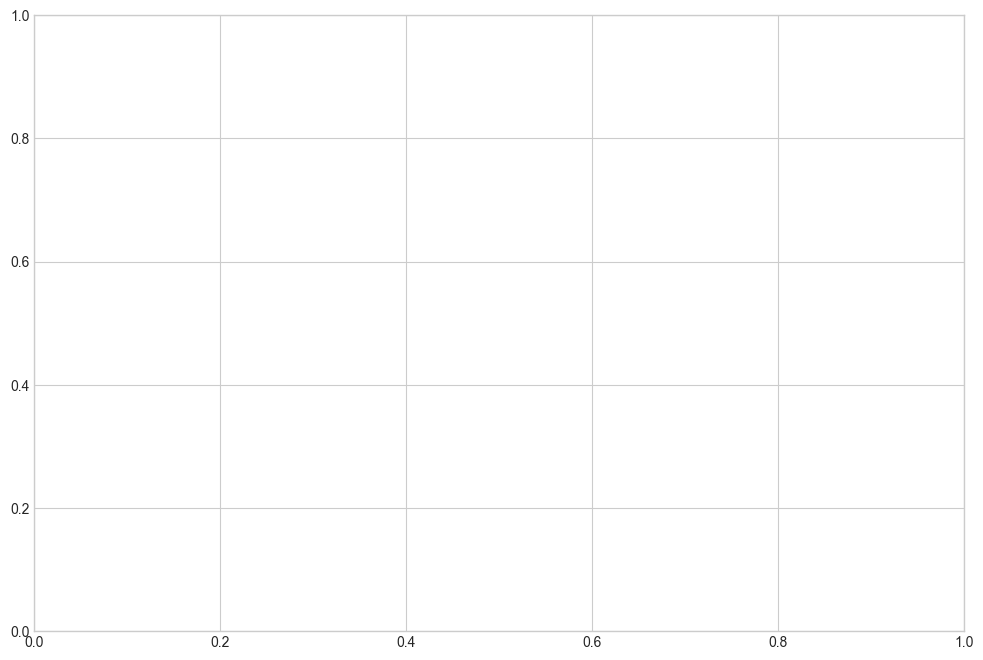

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.font_manager import FontProperties, findSystemFonts

# Function to find Gujarati font
def find_gujarati_font():
    font_names = ['Noto Sans Gujarati', 'Lohit Gujarati', 'Arial Unicode MS']
    font_paths = findSystemFonts(fontpaths=None, fontext='ttf')
    for path in font_paths:
        try:
            font_name = FontProperties(fname=path).get_name()
            if font_name in font_names:
                print(f"Found suitable font: '{font_name}' at {path}")
                return FontProperties(fname=path)
        except RuntimeError:
            continue
    return None

gujarati_font_prop = find_gujarati_font()
if gujarati_font_prop is None:
    print("Could not find a specific Gujarati font. Using default font.")
    gujarati_font_prop = FontProperties()

# Function to plot n-gram probabilities
def plot_ngram_probabilities(ngram_type, ngram_freq, output_filename, top_n=20):
    total_tokens = sum(ngram_freq.values())
    top_ngrams = sorted(ngram_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
    words = [word for word, freq in top_ngrams]
    probabilities = [freq / total_tokens for word, freq in top_ngrams]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x=words, y=probabilities, palette='viridis', ax=ax)

    ax.set_title(f'Top {top_n} {ngram_type} Probabilities in Gujarati Corpus', 
                 fontproperties=gujarati_font_prop, fontsize=16)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_xlabel(f'{ngram_type}s (Words)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontproperties=gujarati_font_prop, fontsize=11)
    plt.tight_layout()
    plt.savefig(output_filename, bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f"\nPlot successfully saved to '{output_filename}'")

# Example usage for unigrams, bigrams, and trigrams
plot_ngram_probabilities("Unigram", unigram_freq, "unigram_probabilities.png")
plot_ngram_probabilities("Bigram", bigram_freq, "bigram_probabilities.png")
plot_ngram_probabilities("Trigram", trigram_freq, "trigram_probabilities.png")